# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is called linear when its coefficients/parameters are linear. This means that the parameters are only multipled by the inputs and added together, not squared or put inside of some other mathematical function.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficient of a dummy variable tells you how much the prediction changes compared to the reference category, holding the other variables fixed. The intercept represents the predicted value for the baseline group, so each dummy coefficient is interpreted relative to that omitted category.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression can technically be used for classification by predicting a number and then applying a cutoff, but it is usually not the best choice. This is because its predictions can go below 0 or above 1, which doesn't really make sense in a classification setting, so methods like logistic regression make more sense for classification.

4. What are signs that your linear model is over-fitting?

One sign of overfitting is that the model does very well on the training data but mworse on the test data. Another sign is that the model becomes overly sensitive to small changes in the data and starts fitting noise instead of the overall trend. 

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity means that two or more predictors contain overlapping information, so it becomes hard for the model to separate their individual effects. As a result, coefficient estimates can become unstable and their standard errors can get large. In a first-stage sense, if one predictor can already be predicted well by the others, then it has little unique variation left to identify its own effect clearly. In the two-stage least squares idea, you first predict the problematic correlated variable using methods, then use that cleaned-up predicted version in the main regression to reduce the distortion caused by that correlation.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can include nonlinear relationships by transforming the inputs, like adding polynomial terms such as `x^2` or `x^3`. This lets a model still be linear in the coefficients while capturing curved or more complex patterns in the data.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient tells you how much the predicted outcome changes when one predictor increases by 1 unit, holding the other variables constant. A positive slope means y tends to increase, while a negative slope means y tends to decrease.

8. Compare the train/test split and $k$-fold cross validation.

A train/test split divides the data once into a training set and a testing set, whereas $k$-fold cross validation repeats the process across multiple splits and averages the results. 

9. How is the $k$ in $k$-fold cross validation typically selected?

The `k` is usually chosen based on a tradeoff between efficiency and accuracy. Numbers between 5-10 are common as they provide a good enough estimate without taking too long to compute, though this depends on use cases.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [12]:
df = pd.read_csv('data/Q1_clean.csv', encoding = 'latin1')
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


                Price  Review Scores Rating
Neighbourhood                              
Manhattan      183.66                 91.80
Staten Island  146.17                 90.84
Brooklyn       127.75                 92.36
Queens          96.86                 91.55
Bronx           75.28                 91.65


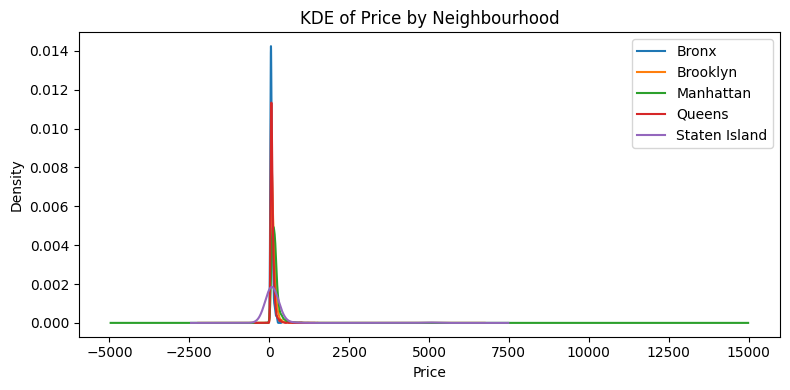

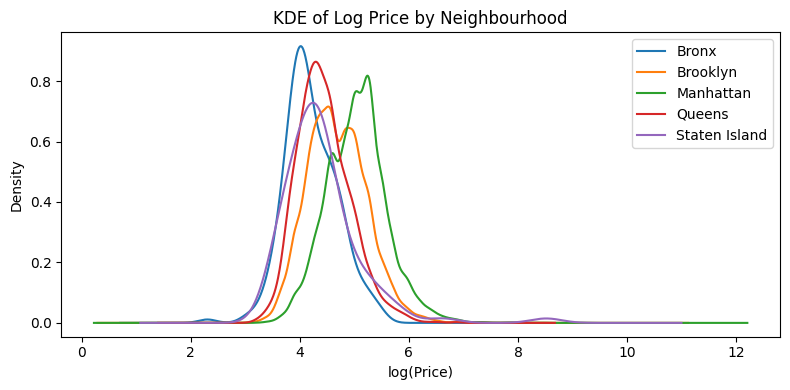

In [13]:
# 2.1
df.columns = df.columns.str.strip()
borough_summary = (
    df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]]
      .mean()
      .sort_values("Price", ascending=False)
)

print(borough_summary.round(2))

# KDE plot for Price
plt.figure(figsize=(8, 4))
for b in sorted(df["Neighbourhood"].unique()):
    df.loc[df["Neighbourhood"] == b, "Price"].plot(kind="kde", label=b)
plt.title("KDE of Price by Neighbourhood")
plt.xlabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

df["log_price"] = np.log(df["Price"])
# KDE plot for log(Price)
plt.figure(figsize=(8, 4))
for b in sorted(df["Neighbourhood"].unique()):
    df.loc[df["Neighbourhood"] == b, "log_price"].plot(kind="kde", label=b)
plt.title("KDE of Log Price by Neighbourhood")
plt.xlabel("log(Price)")
plt.legend()
plt.tight_layout()
plt.show()

Manhattan is the most expensive borough on average.

In [14]:
# 2.2
X2 = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=int)

X2 = sm.add_constant(X2)
y = df["Price"]

m2 = sm.OLS(y, X2).fit()
print(m2.summary())
print(m2.params.round(3))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        03:31:39   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

Because we dropped the first category (Bronx) to avoid the dummy variable trap, the intercept `const` represents the average price in the Bronx. The other coefficients represent the exact difference in conditional group means between that specific neighborhood and the Bronx. If you add a neighborhood's coefficient to the intercept, it exactly matches that neighborhood's average price from Part 1.

In [15]:
# 2.3
m3 = smf.ols("Price ~ Q('Review Scores Rating')", data=df).fit()
print(m3.summary())
print("\nCoefficients:")
print(m3.params.round(3))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        03:31:40   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

The slope coefficient is about 1.021, so a 1-point increase in Review Scores Rating is associated with about a $1.02 increase in nightly price on average.

In [16]:
# 2.4
m4 = smf.ols("Price ~ Neighbourhood + Q('Review Scores Rating')", data=df).fit()
print(m4.summary())
print("\nCoefficients:")
print(m4.params.round(3))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        03:31:41   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

After controlling for Neighbourhood, the slope on Review Scores Rating increases slightly from about 1.02 to 1.08. This means that within the same neighborhood, a 1-point increase in rating is associated with about a $1.08 higher price. The neighborhood coefficients now represent differences relative to the baseline neighborhood holding rating fixed, so they are no longer just the raw borough mean differences from part 1.

In [17]:
# 2.5 
m5 = smf.ols("Price ~ 1 + Neighbourhood:Q('Review Scores Rating')", data=df).fit()
print(m5.summary())
print("\nCoefficients:")
print(m5.params.round(3))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     236.0
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          2.22e-246
Time:                        03:31:42   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

The slopes are not similar across neighborhoods. Manhattan has the steepest slope (meaning a better rating yields the highest price increase there), while the Bronx and Queens have much flatter slopes, meaning ratings have less impact on price in those areas.

In [18]:
# 2.6
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

df_clean = df.dropna(subset=['Price', 'Review Scores Rating', 'Neighbourhood']).reset_index(drop=True)

def get_cv_rmse(formula, data):
    rmse_list = []
    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test = data.iloc[test_idx]
        model = smf.ols(formula, data=train).fit()
        preds = model.predict(test)
        rmse = np.sqrt(np.mean((test['Price'] - preds)**2))
        rmse_list.append(rmse)
    return np.mean(rmse_list)

print("Model 4 CV RMSE (Additive):", get_cv_rmse("Price ~ Neighbourhood + Q('Review Scores Rating')", df_clean))
print("Model 5 CV RMSE (Interactions):", get_cv_rmse("Price ~ 1 + Neighbourhood:Q('Review Scores Rating')", df_clean))

Model 4 CV RMSE (Additive): 140.51652264524586
Model 5 CV RMSE (Interactions): 140.4320236891333


Cross validation shows that both models perform very similarly, but the interactive model (Model 5) has a slightly lower Root Mean Squared Error (RMSE), meaning it generalizes barely better to unseen data for predicting price. 

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


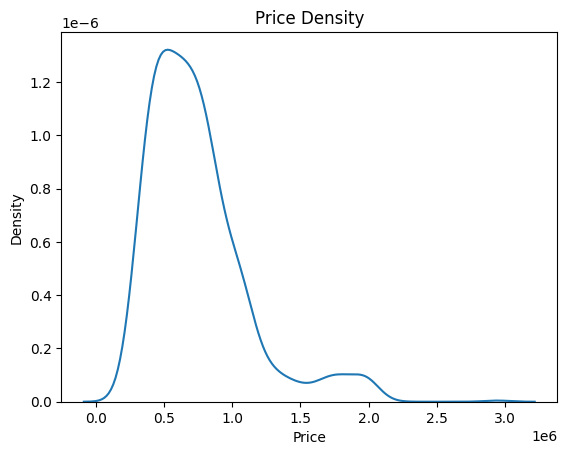


Price Summary by Body Type:
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


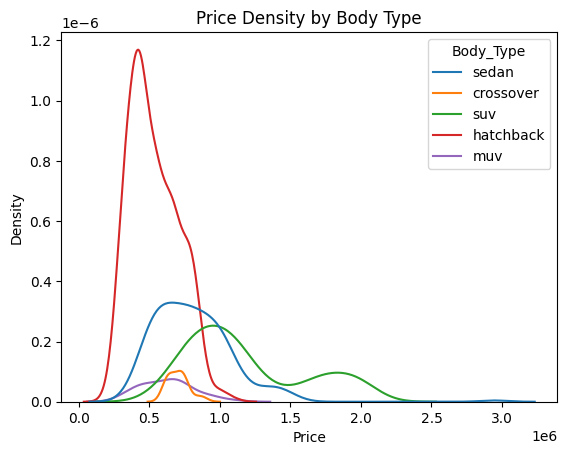

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures

cars = pd.read_csv('data/cars_hw.csv')
print(cars['Price'].describe())

sns.kdeplot(data=cars, x='Price')
plt.title('Price Density')
plt.show()

print("\nPrice Summary by Body Type:")
print(cars.groupby('Body_Type')['Price'].describe())

sns.kdeplot(data=cars, x='Price', hue='Body_Type')
plt.title('Price Density by Body Type')
plt.show()

SUVs generally appear to be the most expensive and have the highest variance, based on the higher mean and standard deviation compared to other body types.

In [21]:
# 3.2
from sklearn.linear_model import LinearRegression

# Standard regression
X_seat = cars[['Seating_Capacity']]
y = cars['Price']
lr_seat = LinearRegression()
lr_seat.fit(X_seat, y)
print(f"Slope coefficient (numeric): {lr_seat.coef_[0]:.2f}")

# Categorical regression (One-hot encoding)
X_seat_cat = pd.get_dummies(cars['Seating_Capacity'], drop_first=True)
lr_seat_cat = LinearRegression()
lr_seat_cat.fit(X_seat_cat, y)
print("\nCoefficients when treating Seating Capacity as categorical:")
print(pd.Series(lr_seat_cat.coef_, index=X_seat_cat.columns).round(2))

Slope coefficient (numeric): 59268.00

Coefficients when treating Seating Capacity as categorical:
5     546483.87
6    1456000.00
7     735948.72
8     271800.00
dtype: float64


The numeric regression gives a slope of about 59,268, meaning that each additional seat is associated with about 59,268 more rupees in price on average. But when seating capacity is treated as categorical, the differences are not evenly spaced, so the relationship does not look very linear.

In [22]:
# 3.3
cars['Age'] = 2026 - cars['Make_Year']

kf = KFold(n_splits=10, shuffle=True, random_state=42)
best_degree, min_error = 1, float('inf')
cv_errors = []

for degree in range(1, 10):
    poly = PolynomialFeatures(degree, include_bias=False)
    X_poly = poly.fit_transform(cars[['Age']])
    
    lr_poly = LinearRegression()
    # using negative mean squared error
    scores = -cross_val_score(lr_poly, X_poly, y, cv=kf, scoring='neg_mean_squared_error')
    cv_error = scores.mean()
    cv_errors.append(cv_error)
    
    if cv_error < min_error:
        min_error = cv_error
        best_degree = degree

print(f"Optimal number of powers for Age: {best_degree}")
print(f"CV errors across degrees: {cv_errors}")

Optimal number of powers for Age: 7
CV errors across degrees: [np.float64(97377248063.9968), np.float64(97395705968.63509), np.float64(96743204818.44319), np.float64(96225038252.28287), np.float64(95265035512.70163), np.float64(95358958378.90298), np.float64(94688967601.90962), np.float64(94976179076.87936), np.float64(95006637951.42957)]


Using 10-fold cross validation, the polynomial with the lowest average MSE is degree 7. So among the models tested, including powers of Age up to Age^7 gave the best predictive performance.

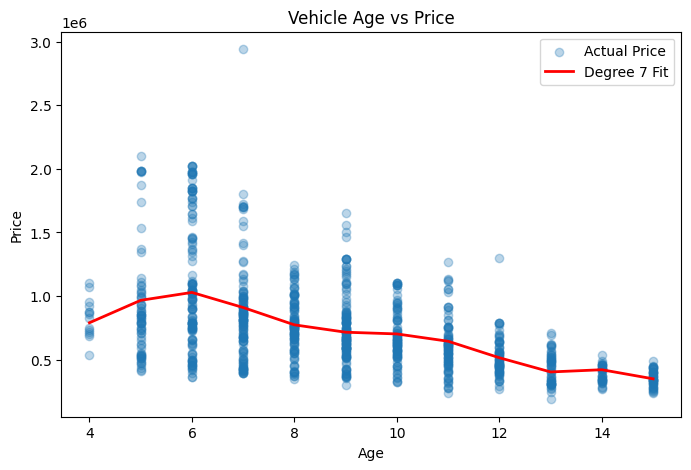

In [23]:
# 3.4
poly_optimal = PolynomialFeatures(best_degree, include_bias=False)
X_age = cars[['Age']]
X_opt = poly_optimal.fit_transform(X_age)

lr_opt = LinearRegression()
lr_opt.fit(X_opt, y)

preds = lr_opt.predict(X_opt)

plt.figure(figsize=(8, 5))
plt.scatter(cars['Age'], y, alpha=0.3, label='Actual Price')

# Sort line by age for clean plotting
sort_idx = np.argsort(X_age['Age'])
plt.plot(X_age['Age'].iloc[sort_idx], preds[sort_idx], color='red', linewidth=2, label=f'Degree {best_degree} Fit')
plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Vehicle Age vs Price')
plt.legend()
plt.show()

The fitted curve captures the general pattern that older cars tend to have lower prices, but there is still a lot of spread in price at each age. So the model picks up the overall trend, but age alone does not fully explain car price.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [24]:
# 4.1
heart = pd.read_csv('data/heart_hw.csv')

# Compute survival proportionally
surv_control = heart[heart['transplant'] == 'control']['y'].mean()
surv_treat = heart[heart['transplant'] == 'treatment']['y'].mean()
ate = surv_treat - surv_control

print("Prop survived (control): " + str(surv_control))
print("Prop survived (treatment): " + str(surv_treat))
print("Average Treatment Effect (ATE): " +str(ate))

Prop survived (control): 0.11764705882352941
Prop survived (treatment): 0.34782608695652173
Average Treatment Effect (ATE): 0.23017902813299232


The control survival rate is about 0.1176, the treatment survival rate is about 0.3478, and the ATE is 0.2302. So receiving a transplant is associated with about a 23 percentage-point increase in three-year survival in this sample.

In [25]:
# 4.2
import statsmodels.formula.api as smf

m4_2 = smf.ols("y ~ transplant", data=heart).fit()
print(m4_2.summary())
print("\nRegression coefficients:")
print(m4_2.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0133
Time:                        03:32:00   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

The intercept, 0.1176, is the survival rate in the control group from part 1. The transplant coefficient, 0.2302, is the difference between the treatment and control survival rates, so it is exactly the ATE from part 1. This means the regression reproduces the same values we computed directly.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000357
Time:                        03:32:01   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

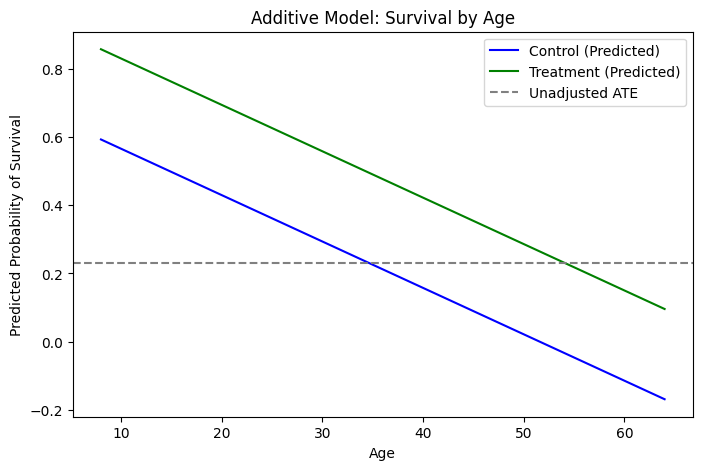

In [26]:
# 4.3
m4_3 = smf.ols("y ~ transplant + age", data=heart).fit()
print(m4_3.summary())

# Create counterfactual dataset for plotting
age_range = np.linspace(heart['age'].min(), heart['age'].max(), 100)

pred_control = m4_3.predict(pd.DataFrame({'transplant': 'control', 'age': age_range}))
pred_treat = m4_3.predict(pd.DataFrame({'transplant': 'treatment', 'age': age_range}))

plt.figure(figsize=(8, 5))
plt.plot(age_range, pred_control, label='Control (Predicted)', color='blue')
plt.plot(age_range, pred_treat, label='Treatment (Predicted)', color='green')
plt.axhline(ate, color='gray', linestyle='--', label='Unadjusted ATE')
plt.xlabel('Age')
plt.ylabel('Predicted Probability of Survival')
plt.title('Additive Model: Survival by Age')
plt.legend()
plt.show()

After controlling for age, the transplant coefficient increases from 0.2302 to about 0.2647. This means that, holding age fixed, treatment is associated with about a 26.5 percentage-point higher probability of three-year survival. The intercept is the predicted survival probability for a control patient at age 0, and the age slope means predicted survival decreases by about 1.36 percentage points per year, holding transplant status fixed. Because this additive model gives the same transplant effect at every age, the raw ATE from part 1 underestimates the transplant effect for all ages.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000310
Time:                        03:32:02   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

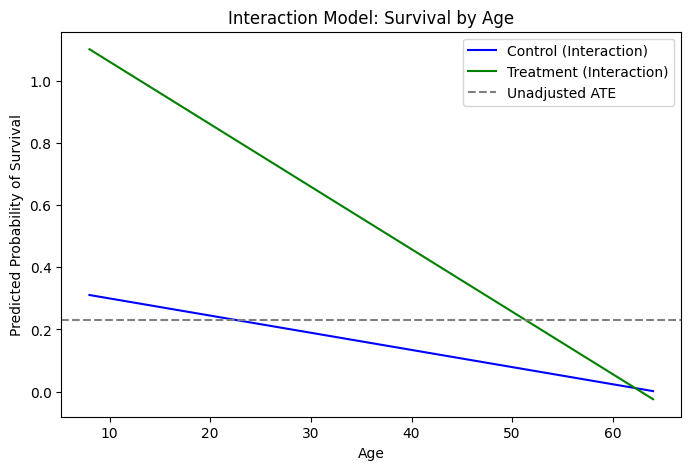

In [27]:
# 4.4
m4_4 = smf.ols("y ~ transplant * age", data=heart).fit()
print(m4_4.summary())

pred_control_int = m4_4.predict(pd.DataFrame({'transplant': 'control', 'age': age_range}))
pred_treat_int = m4_4.predict(pd.DataFrame({'transplant': 'treatment', 'age': age_range}))

plt.figure(figsize=(8, 5))
plt.plot(age_range, pred_control_int, label='Control (Interaction)', color='blue')
plt.plot(age_range, pred_treat_int, label='Treatment (Interaction)', color='green')
plt.axhline(ate, color='gray', linestyle='--', label='Unadjusted ATE')
plt.xlabel('Age')
plt.ylabel('Predicted Probability of Survival')
plt.title('Interaction Model: Survival by Age')
plt.legend()
plt.show()

With the interaction included, the treatment effect depends on age: it is 0.9078 - 0.0146 x age. This means the estimated benefit of transplant is larger for younger patients and gets smaller as age increases. The raw ATE now underestimates the treatment effect for younger patients and overestimates it for older patients.

In [28]:
# 4.5
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def get_cv_rmse(formula, df):
    rmse_list = []
    for train_idx, test_idx in kf.split(df):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]
        model = smf.ols(formula, data=train).fit()
        preds = model.predict(test)
        rmse = np.sqrt(np.mean((test['y'] - preds)**2))
        rmse_list.append(rmse)
    return np.mean(rmse_list)

print("CV RMSE Base (Transplant only):", get_cv_rmse("y ~ transplant", heart))
print("CV RMSE Additive (Transplant + Age):", get_cv_rmse("y ~ transplant + age", heart))
print("CV RMSE Interactive (Transplant * Age):", get_cv_rmse("y ~ transplant * age", heart))

CV RMSE Base (Transplant only): 0.43651009364500126
CV RMSE Additive (Transplant + Age): 0.4166970538535616
CV RMSE Interactive (Transplant * Age): 0.41295572153919097


Using 10-fold cross validation, the interaction model has the lowest RMSE (0.413), followed by the additive model (0.417), and then the transplant-only model (0.437). So adding age improves predictive accuracy, and allowing the transplant effect to vary by age improves it a little more.

**4.6**

A major concern with using this to gate transplant access is that it might systemically bias against older populations receiving potentially necessary and still useful care despite lower generic utility. Furthermore, these basic demographics miss many other health covariates and specific circumstances which can greatly affect decisions. If a simple model like this is used as a gatekeeping tool, it could turn rough statistical patterns into high-stakes decisions and reinforce existing inequities.